# MobileFaceNet

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Add New Embeddings

In [2]:
import os
print(os.getcwd())

/content


In [3]:
# cd to /content/drive/MyDrive/Face_Dataset

%cd /content/drive/MyDrive/Face_Dataset

/content/drive/MyDrive/Face_Dataset


In [ ]:
# Step 1 Clone the MobileFaceNet repository
!git clone https://github.com/foamliu/MobileFaceNet.git

Cloning into 'MobileFaceNet'...
remote: Enumerating objects: 589, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 589 (delta 186), reused 184 (delta 184), pack-reused 383 (from 1)
Receiving objects: 100% (589/589), 5.95 MiB | 9.34 MiB/s, done.
Resolving deltas: 100% (224/224), done.
Updating files: 100% (236/236), done.


In [ ]:
# Step 2: Change directory into the repo
%cd MobileFaceNet

# Step 3: Make a directory for weights
!mkdir -p weights

# Step 4: Change into weights directory
%cd weights

# Step 5: Download the pretrained model
!wget https://github.com/foamliu/MobileFaceNet/releases/download/v1.0/mobilefacenet.pt

/content/drive/MyDrive/Face_Dataset/MobileFaceNet
/content/drive/MyDrive/Face_Dataset/MobileFaceNet/weights
--2025-07-18 17:43:48--  https://github.com/foamliu/MobileFaceNet/releases/download/v1.0/mobilefacenet.pt
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/220410268/00c4f100-0d46-11ea-8422-dff05b11ac5c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-07-18T18%3A34%3A45Z&rscd=attachment%3B+filename%3Dmobilefacenet.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-07-18T17%3A33%3A47Z&ske=2025-07-18T18%3A34%3A45Z&sks=b&skv=2018-11-09&sig=wUmyRsi%2FgcJD0q1tu9uVFNkvuOycOhEQWPJGUAHlH1U%3D&jwt=eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQu

In [4]:
%cd MobileFaceNet

/content/drive/MyDrive/Face_Dataset/MobileFaceNet


In [5]:
from mobilefacenet import MobileFaceNet
import torch
import time

# Load model
filename = 'weights/mobilefacenet.pt'
print(f'Loading {filename}...')
start = time.time()
model = MobileFaceNet()
model.load_state_dict(torch.load(filename, map_location=torch.device('cpu')))
model.eval()
print('Elapsed {:.2f} sec'.format(time.time() - start))


Loading weights/mobilefacenet.pt...
Elapsed 0.74 sec


In [6]:
from PIL import Image
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def get_embedding(image_path):
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0)  # Shape: (1, 3, 112, 112)
    with torch.no_grad():
        embedding = model(input_tensor)
        return embedding.squeeze()  # Shape: (128,)


In [7]:
face_db = {}
face_db['kyle'] = get_embedding('/content/drive/MyDrive/Face_Dataset/MobileFaceNet/my_images/kyle_183.jpg')
face_db['Tom Cruise'] = get_embedding('/content/drive/MyDrive/Face_Dataset/MobileFaceNet/my_images/Tom Cruise_12.jpg')

face_db.keys()

dict_keys(['kyle', 'Tom Cruise'])

In [38]:
# test_embedding = get_embedding('/content/drive/MyDrive/Face_Dataset/MobileFaceNet/my_images/kyle_156.jpg')
# test_embedding = get_embedding('/content/drive/MyDrive/Face_Dataset/processed_whole_face_dataset/val/kyle/kyle_161.jpg')
test_embedding = get_embedding('/content/drive/MyDrive/Face_Dataset/processed_whole_face_dataset/val/Zac Efron/Zac Efron_2.jpg')

# test_embedding = get_embedding('/content/drive/MyDrive/Face_Dataset/processed_whole_face_dataset/val/Tom Cruise/Tom Cruise_37.jpg')

In [36]:
from torch.nn.functional import cosine_similarity

def recognize_face(test_embedding, face_db, threshold=0.6):
    max_sim = 0
    identity = "Unknown"
    for name, db_embedding in face_db.items():
        sim = cosine_similarity(test_embedding.unsqueeze(0), db_embedding.unsqueeze(0))
        if sim.item() > max_sim and sim.item() > threshold:
            max_sim = sim.item()
            identity = name
    return identity, max_sim


In [39]:
# recognize face

identity, confidence = recognize_face(test_embedding, face_db)
print(f"Identified as: {identity} (Confidence: {confidence:.2f})")

Identified as: Unknown (Confidence: 0.00)


## Preprocess Frames

In [ ]:
!pip install mtcnn pillow imgaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.0 MB/s eta 0:00:00


In [ ]:
import os
import random
import shutil
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import imgaug.augmenters as iaa


# --- Configuration ---
RAW_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames"
PROCESSED_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/processed_whole_face_dataset" # Changed output folder name
TRAIN_RATIO = 0.8  # 80% for training, 20% for validation
MAX_IMAGES_PER_SUBJECT = 50

# Target size for the whole face model
TARGET_SIZE = (112, 112)  # Width x Height - Standard size for MobileFaceNet

# --- Augmentation Pipeline ---
# This will be applied ONLY to the training images
augmentation_pipeline = iaa.Sequential([
    iaa.Fliplr(0.5),  # Horizontal flip 50% of the time
    iaa.Multiply((0.8, 1.2), per_channel=0.2), # Brightness/contrast
    iaa.GaussianBlur(sigma=(0, 0.5)),
    # iaa.Affine(rotate=(-8, 8), scale=(0.9, 1.1)) # Added rotation and scaling for more robustness
], random_order=True)


def create_output_dirs(base_path, subjects):
    """Creates the necessary directory structure for whole faces."""
    for subject in subjects:
        os.makedirs(os.path.join(base_path, subject), exist_ok=True)


def process_whole_face(image_np, detector):
    """Detects a face and returns the cropped whole face as a PIL Image."""
    faces = detector.detect_faces(image_np)
    if not faces:
        return None  # No face detected

    face_data = faces[0]  # Assume one face per image for simplicity
    x, y, width, height = face_data['box']

    # Ensure box coordinates are within image bounds
    x, y = max(0, x), max(0, y)

    # Convert to PIL image to crop the main face
    image_pil = Image.fromarray(image_np)
    cropped_face = image_pil.crop((x, y, x + width, y + height))

    return cropped_face


def main():
    """Main function to run the whole-face dataset creation pipeline."""
    # --- 1. Cleanup and Setup ---
    if os.path.exists(PROCESSED_DATASET_PATH):
        print(f"Removing existing processed dataset at '{PROCESSED_DATASET_PATH}'")
        shutil.rmtree(PROCESSED_DATASET_PATH)

    print("Creating new directory structure...")
    train_path = os.path.join(PROCESSED_DATASET_PATH, "train")
    val_path = os.path.join(PROCESSED_DATASET_PATH, "val")
    # No partition subfolders needed
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(val_path, exist_ok=True)

    # --- 2. Identify Subjects ---
    all_subjects = [d for d in os.listdir(RAW_DATASET_PATH) if os.path.isdir(os.path.join(RAW_DATASET_PATH, d))]

    test_subjects = [s for s in all_subjects if s.endswith("_test")]
    train_val_subjects = [s for s in all_subjects if not s.endswith("_test")]

    if not train_val_subjects:
        print("Error: No training subjects found.")
        return

    print(f"Found {len(train_val_subjects)} subjects for Training/Validation: {train_val_subjects}")
    print(f"Found {len(test_subjects)} subjects for held-out Testing: {test_subjects}")
    print("-" * 30)

    # Create directory structures for train and validation sets
    create_output_dirs(train_path, train_val_subjects)
    create_output_dirs(val_path, train_val_subjects)

    print("Initializing MTCNN face detector...")
    detector = MTCNN()

    # --- 3. Process Images for Train/Val Subjects ---
    for subject in train_val_subjects:
        print(f"Processing subject: {subject}")
        subject_path = os.path.join(RAW_DATASET_PATH, subject)

        all_image_files = [f for f in os.listdir(subject_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if len(all_image_files) > MAX_IMAGES_PER_SUBJECT:
            print(f"  - Subject has {len(all_image_files)} images. Randomly selecting {MAX_IMAGES_PER_SUBJECT}.")
            image_files_to_process = random.sample(all_image_files, MAX_IMAGES_PER_SUBJECT)
        else:
            print(f"  - Subject has {len(all_image_files)} images (within the limit).")
            image_files_to_process = all_image_files

        random.shuffle(image_files_to_process)
        split_index = int(len(image_files_to_process) * TRAIN_RATIO)
        train_files = image_files_to_process[:split_index]
        val_files = image_files_to_process[split_index:]

        # Process training files with augmentation
        print(f"  - Processing {len(train_files)} images for training set...")
        for i, filename in enumerate(train_files):
            image_path = os.path.join(subject_path, filename)
            try:
                image_np = np.asarray(Image.open(image_path).convert('RGB'))
                whole_face_image = process_whole_face(image_np, detector)

                if whole_face_image:
                    resized_face = whole_face_image.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

                    # Apply augmentation
                    augmented_np = augmentation_pipeline(image=np.array(resized_face))
                    augmented_image = Image.fromarray(augmented_np)

                    # Save the augmented image
                    save_folder = os.path.join(train_path, subject)
                    augmented_image.save(os.path.join(save_folder, f"{i:03d}_{filename}"))
            except Exception as e:
                print(f"    - Could not process {image_path}: {e}")

        # Process validation files without augmentation
        print(f"  - Processing {len(val_files)} images for validation set...")
        for i, filename in enumerate(val_files):
            image_path = os.path.join(subject_path, filename)
            try:
                image_np = np.asarray(Image.open(image_path).convert('RGB'))
                whole_face_image = process_whole_face(image_np, detector)

                if whole_face_image:
                    resized_face = whole_face_image.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

                    # Save the original resized image
                    save_folder = os.path.join(val_path, subject)
                    resized_face.save(os.path.join(save_folder, filename))
            except Exception as e:
                print(f"    - Could not process {image_path}: {e}")

    print("\n" + "=" * 50)
    print("Dataset processing complete!")
    print(f"Processed data saved in: '{PROCESSED_DATASET_PATH}'")
    print("You are now ready to train a single baseline model on this whole-face dataset.")
    print("=" * 50)


if __name__ == "__main__":
    main()

Creating new directory structure...
Found 4 subjects for Training/Validation: ['Tom Cruise', 'Zac Efron', 'kyle', '.ipynb_checkpoints']
Found 1 subjects for held-out Testing: ['Robert Downey Jr_test']
------------------------------
Initializing MTCNN face detector...
Processing subject: Tom Cruise
  - Subject has 58 images. Randomly selecting 50.
  - Processing 40 images for training set...
  - Processing 10 images for validation set...
Processing subject: Zac Efron
  - Subject has 91 images. Randomly selecting 50.
  - Processing 40 images for training set...
  - Processing 10 images for validation set...
Processing subject: kyle
  - Subject has 204 images. Randomly selecting 50.
  - Processing 40 images for training set...
  - Processing 10 images for validation set...
Processing subject: .ipynb_checkpoints
  - Subject has 0 images (within the limit).
  - Processing 0 images for training set...
  - Processing 0 images for validation set...

Dataset processing complete!
Processed data 

In [ ]:
import os
import re

def remove_copy_prefix_with_number(directory):
    pattern = re.compile(r'^Copy of \d{3}_')  # Matches "Copy of " + exactly 3 digits + "_"

    for filename in os.listdir(directory):
        match = pattern.match(filename)
        if match:
            new_name = filename[match.end():]  # Remove matched prefix
            src = os.path.join(directory, filename)
            dst = os.path.join(directory, new_name)
            os.rename(src, dst)
            print(f'Renamed: {filename} → {new_name}')
        else:
            print(f'Skipped: {filename}')

if __name__ == '__main__':
    folder_path = '/content/drive/MyDrive/Face_Dataset/MobileFaceNet/my_images'  # ⚠️ Change this to your actual directory
    remove_copy_prefix_with_number(folder_path)


Renamed: Copy of 005_kyle_8.jpg → kyle_8.jpg
Renamed: Copy of 015_kyle_191.jpg → kyle_191.jpg
Renamed: Copy of 004_kyle_156.jpg → kyle_156.jpg
Renamed: Copy of 025_kyle_183.jpg → kyle_183.jpg
Renamed: Copy of 006_kyle_26.jpg → kyle_26.jpg
Renamed: Copy of 037_Tom Cruise_31.jpg → Tom Cruise_31.jpg
Renamed: Copy of 019_Tom Cruise_13.jpg → Tom Cruise_13.jpg
Renamed: Copy of 015_Tom Cruise_49.jpg → Tom Cruise_49.jpg
Renamed: Copy of 011_Tom Cruise_50.jpg → Tom Cruise_50.jpg
Renamed: Copy of 002_Tom Cruise_12.jpg → Tom Cruise_12.jpg
Renamed: Copy of 001_Tom Cruise_2.jpg → Tom Cruise_2.jpg


# **Face Recognition Model Training**

Install libraries

In [ ]:
!pip install mtcnn tensorflow pillow imgaug opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.7 MB/s eta 0:00:00


In [ ]:
!pip install "numpy<2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 470.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 25.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


Import necessary libraries

In [ ]:
# Import libraries
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import os
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

# Fix for numpy 2.0 compatibility issue with imgaug
# import imgaug.random_state
# imgaug.random_state.np = np

## Extract Frames from Video

In [ ]:
import cv2
import os

# 📁 Set your video file path
video_path = '/content/drive/MyDrive/Face_Dataset/kyle.mp4'
output_dir = '/content/drive/MyDrive/Face_Dataset/extracted_frames'
frame_interval = 5  # Extract every 5th frame

In [ ]:
# Extract base name without extension
video_filename = os.path.splitext(os.path.basename(video_path))[0]

# Create output directory
output_dir += f'/{video_filename}'
os.makedirs(output_dir, exist_ok=True)

# Load video
cap = cv2.VideoCapture(video_path)

frame_id = 0
saved_frame_count = 0
success = True

print(f"Extracting every {frame_interval} frames from: {video_path}")

while success:
    success, frame = cap.read()
    if not success:
        break

    if frame_id % frame_interval == 0:
        saved_frame_count += 1
        frame_filename = f"{video_filename}_{saved_frame_count}.jpg"
        output_path = os.path.join(output_dir, frame_filename)
        cv2.imwrite(output_path, frame)

    frame_id += 1

cap.release()
print(f"Done! {saved_frame_count} frames saved in '{output_dir}' folder.")


Extracting every 5 frames from: /content/drive/MyDrive/Face_Dataset/kyle.mp4
Done! 207 frames saved in '/content/drive/MyDrive/Face_Dataset/extracted_frames/kyle' folder.


## Data Preprocessing
involves grayscale, face detection, face alignment & cropping, face partition, and resize partitions

In [ ]:
import os
import random
import shutil
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

# --- Configuration ---
RAW_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames"
PROCESSED_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/processed2_dataset"
TRAIN_RATIO = 0.8  # 80% for training, 20% for validation
MAX_IMAGES_PER_SUBJECT = 50

# These sizes are what the models will expect as input.
TARGET_SIZES = {
    "top": (112, 64),    # Width x Height
    "mid": (112, 28), # initially 112, 56
    "bottom": (112, 64)
}

# --- Augmentation Pipeline ---
# This will be applied ONLY to the training images
augmentation_pipeline = iaa.Sequential([
    iaa.Fliplr(0.5),  # Horizontal flip 50% of the time
    iaa.Multiply((0.8, 1.2), per_channel=0.2), # Brightness/contrast
    iaa.GaussianBlur(sigma=(0, 0.5)),
    # iaa.Affine(rotate=(-8, 8), scale=(0.9, 1.1)) # Slight rotation and scaling
], random_order=True)


def create_output_dirs(base_path, subjects, partitions=["top", "mid", "bottom"]):
    """Creates the necessary directory structure."""
    for subject in subjects:
        for part in partitions:
            os.makedirs(os.path.join(base_path, part, subject), exist_ok=True)


def process_and_partition_face(image_np, detector):
    """Detects a face and returns the three landmark-based partitions."""
    faces = detector.detect_faces(image_np)
    if not faces:
        return None  # No face detected

    face_data = faces[0]  # one face per image for simplicity
    x, y, width, height = face_data['box']

    # Ensure box coordinates are within image bounds
    x, y = max(0, x), max(0, y)

    landmarks = face_data['keypoints']

    # Convert to PIL image to crop the main face
    image_pil = Image.fromarray(image_np)
    cropped_face = image_pil.crop((x, y, x + width, y + height))

    # Get relative landmark coordinates
    left_eye_rel = (landmarks['left_eye'][0] - x, landmarks['left_eye'][1] - y)
    right_eye_rel = (landmarks['right_eye'][0] - x, landmarks['right_eye'][1] - y)
    mouth_left_rel = (landmarks['mouth_left'][0] - x, landmarks['mouth_left'][1] - y)
    mouth_right_rel = (landmarks['mouth_right'][0] - x, landmarks['mouth_right'][1] - y)

    # Calculate cut lines based on landmarks
    eye_level_y = (left_eye_rel[1] + right_eye_rel[1]) / 2
    mouth_level_y = (mouth_left_rel[1] + mouth_right_rel[1]) / 2

    # Add some padding to avoid cutting right through features
    cut_line_1 = int(eye_level_y + height * 0.10)
    cut_line_2 = int(mouth_level_y - height * 0.10)

    # Sanity checks for cut lines
    cut_line_1 = max(0, min(cut_line_1, height))
    cut_line_2 = max(0, min(cut_line_2, height))

    # Fallback if landmarks are weirdly positioned
    if cut_line_1 >= cut_line_2:
        print("Warning: Landmark-based cuts failed, using ratio-based fallback.")
        cut_line_1, cut_line_2 = int(height * 0.40), int(height * 0.65)

    face_width = cropped_face.width
    partitions = {
        "top": cropped_face.crop((0, 0, face_width, cut_line_1)),
        "mid": cropped_face.crop((0, cut_line_1, face_width, cut_line_2)),
        "bottom": cropped_face.crop((0, cut_line_2, face_width, height))
    }
    return partitions


def main():
    """Main function to run the dataset creation pipeline."""
    # --- 1. Cleanup and Setup ---
    if os.path.exists(PROCESSED_DATASET_PATH):
        print(f"Removing existing processed dataset at '{PROCESSED_DATASET_PATH}'")
        shutil.rmtree(PROCESSED_DATASET_PATH)

    print("Creating new directory structure...")
    train_path = os.path.join(PROCESSED_DATASET_PATH, "train")
    val_path = os.path.join(PROCESSED_DATASET_PATH, "val")
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(val_path, exist_ok=True)

    # --- 2. Identify Subjects and Split them ---
    all_subjects = [d for d in os.listdir(RAW_DATASET_PATH) if os.path.isdir(os.path.join(RAW_DATASET_PATH, d))]

    # IMPORTANT: Identify test subjects who will be completely held out
    test_subjects = [s for s in all_subjects if s.endswith("_test")]
    train_val_subjects = [s for s in all_subjects if not s.endswith("_test")]

    if not train_val_subjects:
        print("Error: No training subjects found. Please name your training folders without '_test' at the end.")
        return

    print(f"Found {len(train_val_subjects)} subjects for Training/Validation: {train_val_subjects}")
    print(f"Found {len(test_subjects)} subjects for held-out Testing: {test_subjects}")
    print("-" * 30)

    # Create directory structures for train and validation sets
    create_output_dirs(train_path, train_val_subjects)
    create_output_dirs(val_path, train_val_subjects)

    # Initialize the face detector
    print("Initializing MTCNN face detector...")
    detector = MTCNN()

    # --- 3. Process Images for Train/Val Subjects ---
    for subject in train_val_subjects:
        print(f"Processing subject: {subject}")
        subject_path = os.path.join(RAW_DATASET_PATH, subject)

         # Get all available image files
        all_image_files = [f for f in os.listdir(subject_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # LIMIT THE NUMBER OF IMAGES PER SUBJECT
        if len(all_image_files) > MAX_IMAGES_PER_SUBJECT:
            print(f"  - Subject has {len(all_image_files)} images. Randomly selecting {MAX_IMAGES_PER_SUBJECT}.")
            image_files_to_process = random.sample(all_image_files, MAX_IMAGES_PER_SUBJECT)
        else:
            print(f"  - Subject has {len(all_image_files)} images (within the limit).")
            image_files_to_process = all_image_files

        # Shuffle the selected files for random train/val split
        random.shuffle(image_files_to_process)
        split_index = int(len(image_files_to_process) * TRAIN_RATIO)
        train_files = image_files_to_process[:split_index]
        val_files = image_files_to_process[split_index:]

        # Process training files with augmentation
        for i, filename in enumerate(train_files):
            image_path = os.path.join(subject_path, filename)
            try:
                image_np = np.asarray(Image.open(image_path).convert('RGB'))
                partitions = process_and_partition_face(image_np, detector)
                if partitions:
                    for part_name, part_image in partitions.items():
                        resized_part = part_image.resize(TARGET_SIZES[part_name], Image.Resampling.LANCZOS)

                        # Apply augmentation
                        augmented_np = augmentation_pipeline(image=np.array(resized_part))
                        augmented_image = Image.fromarray(augmented_np)

                        # Save the augmented image
                        save_folder = os.path.join(train_path, part_name, subject)
                        augmented_image.save(os.path.join(save_folder, f"{i:03d}_{filename}"))
            except Exception as e:
                print(f"  - Could not process {image_path}: {e}")

        # Process validation files without augmentation
        print(f"  - Processing {len(val_files)} images for validation set...")
        for i, filename in enumerate(val_files):
            image_path = os.path.join(subject_path, filename)
            try:
                image_np = np.asarray(Image.open(image_path).convert('RGB'))
                partitions = process_and_partition_face(image_np, detector)
                if partitions:
                    for part_name, part_image in partitions.items():
                        resized_part = part_image.resize(TARGET_SIZES[part_name], Image.Resampling.LANCZOS)

                        # Save the original resized image (no augmentation)
                        save_folder = os.path.join(val_path, part_name, subject)
                        resized_part.save(os.path.join(save_folder, filename))
            except Exception as e:
                print(f"  - Could not process {image_path}: {e}")

    print("\n" + "=" * 50)
    print("Dataset processing complete!")
    print(f"Processed data saved in: '{PROCESSED_DATASET_PATH}'")
    print("You are now ready to train your three separate models on the 'top', 'mid', and 'bottom' folders within 'train' and 'val'.")
    print("=" * 50)



main()

Removing existing processed dataset at '/content/drive/MyDrive/Face_Dataset/processed2_dataset'
Creating new directory structure...
Found 4 subjects for Training/Validation: ['Tom Cruise', 'Zac Efron', 'kyle', '.ipynb_checkpoints']
Found 1 subjects for held-out Testing: ['Robert Downey Jr_test']
------------------------------
Initializing MTCNN face detector...
Processing subject: Tom Cruise
  - Subject has 58 images. Randomly selecting 50.
  - Processing 10 images for validation set...
Processing subject: Zac Efron
  - Subject has 91 images. Randomly selecting 50.
  - Processing 10 images for validation set...
Processing subject: kyle
  - Subject has 204 images. Randomly selecting 50.
  - Processing 10 images for validation set...
Processing subject: .ipynb_checkpoints
  - Subject has 0 images (within the limit).
  - Processing 0 images for validation set...

Dataset processing complete!
Processed data saved in: '/content/drive/MyDrive/Face_Dataset/processed2_dataset'
You are now read

### Preprocess one image

In [ ]:
detector = MTCNN()
image_np = np.asarray(Image.open("/content/drive/MyDrive/Face_Dataset/extracted_frames/kyle/kyle_22.jpg").convert('RGB'))
partitions = process_and_partition_face(image_np, detector)
if partitions:
    for part_name, part_image in partitions.items():
        resized_part = part_image.resize(TARGET_SIZES[part_name], Image.Resampling.LANCZOS)

        # Apply augmentation
        augmented_np = augmentation_pipeline(image=np.array(resized_part))
        augmented_image = Image.fromarray(augmented_np)

        # Save the augmented image
        save_folder = os.path.join("/content/drive/MyDrive/Face_Dataset/")
        augmented_image.save(os.path.join(save_folder, f"{part_name}_kyle_22.jpg"))

## Model Training

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import regularizers, Model, mixed_precision
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                    DepthwiseConv2D, Add, Dense, Flatten, Lambda,
                                    Dropout, RandomFlip, RandomRotation, RandomZoom)
from tensorflow.keras import backend as K
import math

# Enable mixed precision for faster training
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# --- Configuration ---
PROCESSED_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset"
BATCH_SIZE = 8
INITIAL_LR = 0.0005
NUM_EPOCHS = 30

# Linear warmup + cosine decay
def lr_schedule(epoch):
    warmup_epochs = 5
    if epoch < warmup_epochs:
        return INITIAL_LR * (epoch + 1) / warmup_epochs
    return 0.5 * INITIAL_LR * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (NUM_EPOCHS - warmup_epochs)))

optimizer = tf.keras.optimizers.Adam(learning_rate=INITIAL_LR)

# Define the partitions and their specific input shapes
PARTITIONS_CONFIG = {
    "top": {"shape": (64, 112, 3)},
    "mid": {"shape": (56, 112, 3)},
    "bottom": {"shape": (64, 112, 3)}
}

def build_mobilefacenet(input_shape, num_classes, model_name):
    inputs = Input(shape=input_shape)

    # Enhanced augmentation
    x = RandomFlip("horizontal")(inputs)
    x = RandomRotation(0.05)(x)  # Reduced rotation
    x = (x - 127.5) / 128.0

    # Simplified feature extractor
    x = Conv2D(16, 3, strides=2, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(32, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Flatten()(x)

    # Classification head with regularization
    x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)


def main():
    for part_name, config in PARTITIONS_CONFIG.items():
        print("\n" + "="*20 + f" Training Model for '{part_name}' Partition " + "="*20)

        train_dir = os.path.join(PROCESSED_DATASET_PATH, "train", part_name)
        val_dir = os.path.join(PROCESSED_DATASET_PATH, "val", part_name)

        if not os.path.isdir(train_dir) or not os.path.isdir(val_dir):
            print(f"Error: Directories for partition '{part_name}' not found.")
            continue

        # Get all class directories that contain images
        valid_classes = []
        class_counts = []

        for class_dir in sorted(os.listdir(train_dir)):
            class_dir_path = os.path.join(train_dir, class_dir)
            if os.path.isdir(class_dir_path):
                num_images = len([f for f in os.listdir(class_dir_path)
                                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                if num_images > 0:  # Only include classes with images
                    valid_classes.append(class_dir)
                    class_counts.append(num_images)

        if not valid_classes:
            print(f"Error: No valid classes found in {train_dir}")
            continue

        # Calculate class weights
        total_samples = sum(class_counts)
        class_weights = {
            i: total_samples / (len(class_counts) * count)
            for i, count in enumerate(class_counts)
        }

        print(f"\nClass distribution for {part_name}:")
        for class_name, weight in zip(valid_classes, class_weights.values()):
            print(f"  {class_name}: weight={weight:.2f}")

        # Load datasets
        input_shape = config["shape"]
        image_size = (input_shape[0], input_shape[1])

        train_dataset = tf.keras.utils.image_dataset_from_directory(
            train_dir,
            label_mode='int',
            image_size=image_size,
            batch_size=BATCH_SIZE,
            shuffle=True
        )

        val_dataset = tf.keras.utils.image_dataset_from_directory(
            val_dir,
            label_mode='int',
            image_size=image_size,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        # Build and compile model
        model = build_mobilefacenet(input_shape, len(class_counts), f"MobileFaceNet_{part_name}")


        model.compile(
            optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train with enhanced callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            ),
            tf.keras.callbacks.LearningRateScheduler(lr_schedule),
            tf.keras.callbacks.ModelCheckpoint(
                'best_model.keras',
                monitor='val_accuracy',
                save_best_only=True
            )
        ]

        print(f"\nStarting training for {part_name} model...")
        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=NUM_EPOCHS,
            class_weight=class_weights,
            callbacks=callbacks,
            verbose=1
        )

        save_path = f"/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_{part_name}.keras"
        model.save(save_path, save_format='keras')  # Explicit format specification
        print(f"Model saved in modern Keras format to {save_path}")

main()


==================== Training Model for 'top' Partition ====================

Class distribution for top:
  Tom Cruise: weight=1.00
  Zac Efron: weight=1.00
  kyle: weight=1.00
Found 120 files belonging to 3 classes.
Found 30 files belonging to 3 classes.

Starting training for top model...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 971ms/step - accuracy: 0.4343 - loss: 1.4847 - val_accuracy: 0.8333 - val_loss: 0.9727 - learning_rate: 6.0000e-05
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 923ms/step - accuracy: 0.7170 - loss: 1.0370 - val_accuracy: 0.8333 - val_loss: 0.9355 - learning_rate: 1.2000e-04
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 876ms/step - accuracy: 0.8290 - loss: 0.4684 - val_accuracy: 0.8000 - val_loss: 0.9008 - learning_rate: 1.8000e-04
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 935ms/step - accuracy: 0.8661 - loss: 0.5179 - val_accuracy: 0.6333 - val_loss: 0.9435 - learning_rate: 2.4000e-04
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 920ms/step - accuracy: 0.7754 - loss:

Model saved in modern Keras format to /content/drive/MyDrive/Face_Dataset/mobilefacenet_model_top.keras

==================== Training Model for 'mid' Partition ====================

Class distribution for mid:
  Tom Cruise: weight=1.00
  Zac Efron: weight=1.00
  kyle: weight=1.00
Found 120 files belonging to 3 classes.
Found 30 files belonging to 3 classes.

Starting training for mid model...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 928ms/step - accuracy: 0.4010 - loss: 1.4358 - val_accuracy: 0.3667 - val_loss: 1.1102 - learning_rate: 6.0000e-05
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 780ms/step - accuracy: 0.6037 - loss: 1.6774 - val_accuracy: 0.6333 - val_loss: 1.0922 - learning_rate: 1.2000e-04
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 822ms/step - accuracy: 0.5795 - loss: 1.7091 - val_accuracy: 0.4667 - val_loss: 0.9896 - learning_rate: 1.8000e-04
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 825ms/step - accuracy: 0.7001 - loss: 1.4485 - val_accuracy: 0.4000 - val_loss: 1.0889 - l

Model saved in modern Keras format to /content/drive/MyDrive/Face_Dataset/mobilefacenet_model_mid.keras

==================== Training Model for 'bottom' Partition ====================

Class distribution for bottom:
  Tom Cruise: weight=1.00
  Zac Efron: weight=1.00
  kyle: weight=1.00
Found 120 files belonging to 3 classes.
Found 30 files belonging to 3 classes.

Starting training for bottom model...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 976ms/step - accuracy: 0.3422 - loss: 1.7125 - val_accuracy: 0.3667 - val_loss: 1.1018 - learning_rate: 6.0000e-05
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 848ms/step - accuracy: 0.5550 - loss: 1.2401 - val_accuracy: 0.3667 - val_loss: 1.0940 - learning_rate: 1.2000e-04
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 866ms/step - accuracy: 0.6853 - loss: 0.8361 - val_accuracy: 0.5000 - val_loss: 1.0832 - learning_rate: 1.8000e-04
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 949ms/step - accuracy: 0.7880 - loss: 0.7563 - val_accuracy: 0.6333 - val_loss: 1

Model saved in modern Keras format to /content/drive/MyDrive/Face_Dataset/mobilefacenet_model_bottom.keras


## Model Training (Transfer Learning)

In [ ]:
!pip install torch torchaudio torchvision requests pillow matplotlib requests tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
import requests
from tqdm import tqdm

In [ ]:
# Global Configuration
GLOBAL_CONFIG = {
    "BASE_PATH": "/content/drive/MyDrive/Face_Dataset/processed_dataset",
    # "PRETRAINED_MODEL_URL": "https://github.com/foamliu/MobileFaceNet/releases/download/v1.0/mobilefacenet.pt",
    "PRETRAINED_MODEL_PATH": "/content/drive/MyDrive/Face_Dataset/mobilefacenet.pt",
    "ROOT_PATH": "/content/drive/MyDrive/Face_Dataset/",
    "NUM_SUBJECTS": 3,
    "TRAIN_IMAGES_PER_SUBJECT": 40,
    "VAL_IMAGES_PER_SUBJECT": 10,
    "BATCH_SIZE": 16,
    "LEARNING_RATE": 0.001,
    "NUM_EPOCHS": 50,
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

PARTITIONS_CONFIG = {
    "top": {"shape": (64, 112, 3)},
    "mid": {"shape": (56, 112, 3)},
    "bottom": {"shape": (64, 112, 3)}
}

class MobileFaceNet(nn.Module):
    """MobileFaceNet architecture for face recognition"""
    def __init__(self, num_classes=3):
        super(MobileFaceNet, self).__init__()
        # This is a simplified version - you'll need to adapt based on actual MobileFaceNet structure
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

class FaceDataset(Dataset):
    """Custom dataset for face recognition with partition-specific transforms"""
    def __init__(self, data_path, partition, transform=None):
        self.data_path = data_path
        self.partition = partition
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.classes = []

        # Load data
        self._load_data()

    def _load_data(self):
        partition_path = os.path.join(self.data_path, self.partition)

        # Get class names (subject names), filtering out hidden/system folders
        all_items = os.listdir(partition_path)
        self.classes = sorted([
            item for item in all_items
            if os.path.isdir(os.path.join(partition_path, item))
            and not item.startswith('.')
            and item not in ['__pycache__', '.ipynb_checkpoints']
        ])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        # Load samples
        for class_name in self.classes:
            class_path = os.path.join(partition_path, class_name)
            if os.path.isdir(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_path, img_name)
                        self.samples.append((img_path, self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label


def get_transforms(partition):
    """Get transforms for specific partition"""
    height, width = PARTITIONS_CONFIG[partition]["shape"][:2]

    train_transform = transforms.Compose([
        transforms.Resize((height, width)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((height, width)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform

def create_dataloaders(partition):
    """Create dataloaders for training and validation"""
    train_transform, val_transform = get_transforms(partition)

    train_dataset = FaceDataset(
        os.path.join(GLOBAL_CONFIG["BASE_PATH"], "train"),
        partition,
        transform=train_transform
    )

    val_dataset = FaceDataset(
        os.path.join(GLOBAL_CONFIG["BASE_PATH"], "val"),
        partition,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=GLOBAL_CONFIG["BATCH_SIZE"],
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=GLOBAL_CONFIG["BATCH_SIZE"],
        shuffle=False,
        num_workers=2
    )

    return train_loader, val_loader, train_dataset.classes

def load_pretrained_model():
    """Load pretrained MobileFaceNet and adapt for transfer learning"""
    try:
        # Load pretrained weights
        pretrained_state = torch.load(GLOBAL_CONFIG["PRETRAINED_MODEL_PATH"], map_location=GLOBAL_CONFIG["DEVICE"])

        # Create model
        model = MobileFaceNet(num_classes=GLOBAL_CONFIG["NUM_SUBJECTS"])

        # Load pretrained weights (excluding classifier)
        model_dict = model.state_dict()
        pretrained_dict = {k: v for k, v in pretrained_state.items()
                          if k in model_dict and 'classifier' not in k}
        model_dict.update(pretrained_dict)
        model.load_state_dict(model_dict)

        # Freeze feature layers for transfer learning
        for param in model.features.parameters():
            param.requires_grad = False

        return model
    except Exception as e:
        print(f"Error loading pretrained model: {e}")
        print("Using randomly initialized model...")
        return MobileFaceNet(num_classes=GLOBAL_CONFIG["NUM_SUBJECTS"])

def train_model(model, train_loader, val_loader, partition):
    """Train the model for a specific partition"""
    model = model.to(GLOBAL_CONFIG["DEVICE"])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=GLOBAL_CONFIG["LEARNING_RATE"])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

    train_losses = []
    val_accuracies = []
    best_val_acc = 0.0

    print(f"\nTraining model for partition: {partition}")
    print(f"Device: {GLOBAL_CONFIG['DEVICE']}")

    for epoch in range(GLOBAL_CONFIG["NUM_EPOCHS"]):
        # Training phase
        model.train()
        running_loss = 0.0

        for batch_idx, (data, targets) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{GLOBAL_CONFIG['NUM_EPOCHS']}")):
            data, targets = data.to(GLOBAL_CONFIG["DEVICE"]), targets.to(GLOBAL_CONFIG["DEVICE"])

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Validation phase
        model.eval()
        val_predictions = []
        val_targets = []

        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(GLOBAL_CONFIG["DEVICE"]), targets.to(GLOBAL_CONFIG["DEVICE"])
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)

                val_predictions.extend(predicted.cpu().numpy())
                val_targets.extend(targets.cpu().numpy())

        val_acc = accuracy_score(val_targets, val_predictions)
        epoch_loss = running_loss / len(train_loader)

        train_losses.append(epoch_loss)
        val_accuracies.append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{GLOBAL_CONFIG["ROOT_PATH"]}best_model_{partition}.pth')

        scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{GLOBAL_CONFIG['NUM_EPOCHS']}: "
                  f"Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.4f}")

    print(f"Best validation accuracy for {partition}: {best_val_acc:.4f}")
    return train_losses, val_accuracies, best_val_acc

def evaluate_model(model, val_loader, class_names):
    """Evaluate model and generate classification report"""
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(GLOBAL_CONFIG["DEVICE"]), target.to(GLOBAL_CONFIG["DEVICE"])
            output = model(data)
            _, predicted = torch.max(output.data, 1)

            predictions.extend(predicted.cpu().numpy())
            targehttps://colab.research.google.com/github/Kyle-Santos/named-ai/blob/main/data-preprocessing/preprocess.ipynb#scrollTo=Model_Trainingts.extend(target.cpu().numpy())

    accuracy = accuracy_score(targets, predictions)
    report = classification_report(targets, predictions, target_names=class_names)

    return accuracy, report

def plot_training_history(train_losses, val_accuracies, partition):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses)
    ax1.set_title(f'Training Loss - {partition}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')

    ax2.plot(val_accuracies)
    ax2.set_title(f'Validation Accuracy - {partition}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')

    plt.tight_layout()
    plt.savefig(f'{GLOBAL_CONFIG["ROOT_PATH"]}training_history_{partition}.png')
    plt.show()

def main():
    """Main training pipeline"""
    print("Starting MobileFaceNet Transfer Learning Pipeline")
    print("="*50)

    results = {}

    # Train models for each partition
    for partition in PARTITIONS_CONFIG.keys():
        print(f"\n{'='*20} PARTITION: {partition.upper()} {'='*20}")

        # Create dataloaders
        train_loader, val_loader, class_names = create_dataloaders(partition)
        print(f"Classes: {class_names}")
        print(f"Training samples: {len(train_loader.dataset)}")
        print(f"Validation samples: {len(val_loader.dataset)}")

        # Load pretrained model
        model = load_pretrained_model()

        # Train model
        train_losses, val_accuracies, best_val_acc = train_model(
            model, train_loader, val_loader, partition
        )

        # Load best model for evaluation
        model.load_state_dict(torch.load(f'best_model_{partition}.pth'))

        # Evaluate model
        accuracy, report = evaluate_model(model, val_loader, class_names)

        # Plot training history
        plot_training_history(train_losses, val_accuracies, partition)

        # Store results
        results[partition] = {
            'best_val_acc': best_val_acc,
            'final_accuracy': accuracy,
            'classification_report': report
        }

        print(f"\nFinal Results for {partition}:")
        print(f"Best Validation Accuracy: {best_val_acc:.4f}")
        print(f"Final Test Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(report)

    # Summary of all partitions
    print("\n" + "="*50)
    print("SUMMARY OF ALL PARTITIONS")
    print("="*50)

    for partition, result in results.items():
        print(f"{partition.upper()}: Best Val Acc = {result['best_val_acc']:.4f}")

    print("\nTraining completed successfully!")

main()

Starting MobileFaceNet Transfer Learning Pipeline

==================== PARTITION: TOP ====================
Classes: ['Tom Cruise', 'Zac Efron', 'kyle']
Training samples: 120
Validation samples: 30

Training model for partition: top
Device: cpu


Epoch 1/50:   0%|          | 0/8 [00:00<?, ?it/s]


KeyboardInterrupt: 

## Test Transfer Learning Model

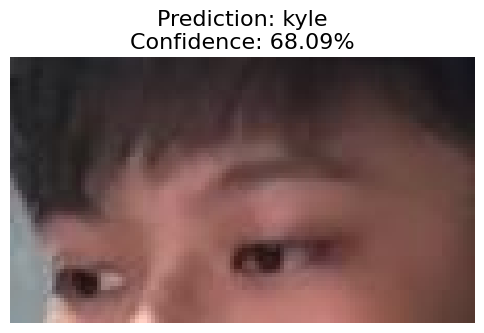

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MobileFaceNet(nn.Module):
    def __init__(self, num_classes=3):
        super(MobileFaceNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

PARTITIONS_CONFIG = {
    "top": {"shape": (64, 112, 3)},
    "mid": {"shape": (56, 112, 3)},
    "bottom": {"shape": (64, 112, 3)}
}

# Must define the class names in the same order they were trained
class_names = ['Tom Cruise', 'Zac Efron', 'kyle']
target_partition = 'bottom'                               # <-- Choose 'top', 'mid', or 'bottom'
image_to_test_path = '/content/drive/MyDrive/Face_Dataset/processed_dataset/val/top/kyle/kyle_113.jpg'    # EDIT PATH FOR TEST IMAGE


# LOAD AND PREPARE THE MODEL AND TRANSFORMS
model_path = f'/content/drive/MyDrive/Face_Dataset/best_model_{target_partition}.pth'
num_classes = len(class_names)
height, width = PARTITIONS_CONFIG[target_partition]["shape"][:2]

val_transform = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

model = MobileFaceNet(num_classes=num_classes)
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# LOAD IMAGE AND MAKE PREDICTION
try:
    image = Image.open(image_to_test_path).convert('RGB')

    image_tensor = val_transform(image)
    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    predicted_class = class_names[predicted_idx.item()]
    confidence_score = confidence.item()

    # 4. DISPLAY THE RESULT
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f'Prediction: {predicted_class}\nConfidence: {confidence_score:.2%}', fontsize=16)
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: The file was not found at '{image_to_test_path}'")
except Exception as e:
    print(f"An error occurred: {e}")

## Archives